In [2]:
# 📘 Conversion Rate Challenge - Starter Notebook

In [3]:
# =============================
# 🔧 1. Imports
# =============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
# =============================
# 📥 2. Load Dataset
# =============================

df = pd.read_csv("../src/conversion_data_train.csv")

In [5]:
# =============================
# 🔍 3. Basic EDA
# =============================

print("\n📊 Dataset Info:")
print(df.info())
print(" ")

print("\n🔎 First Rows:")
print(df.head())
print(" ")

print("\n📉 Missing Values:")
print(df.isnull().sum())
print(" ")

print("\n📊 Target Distribution:")
print(df['converted'].value_counts(normalize=True))




📊 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284580 entries, 0 to 284579
Data columns (total 6 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   country              284580 non-null  object
 1   age                  284580 non-null  int64 
 2   new_user             284580 non-null  int64 
 3   source               284580 non-null  object
 4   total_pages_visited  284580 non-null  int64 
 5   converted            284580 non-null  int64 
dtypes: int64(4), object(2)
memory usage: 13.0+ MB
None
 

🔎 First Rows:
   country  age  new_user  source  total_pages_visited  converted
0    China   22         1  Direct                    2          0
1       UK   21         1     Ads                    3          0
2  Germany   20         0     Seo                   14          1
3       US   23         1     Seo                    3          0
4       US   28         1  Direct                    3          0
 

📉

In [6]:
# =============================
# ✅ First conclusions
# =============================

# - No missing values
# - Conversion rate is quite low - about 3%


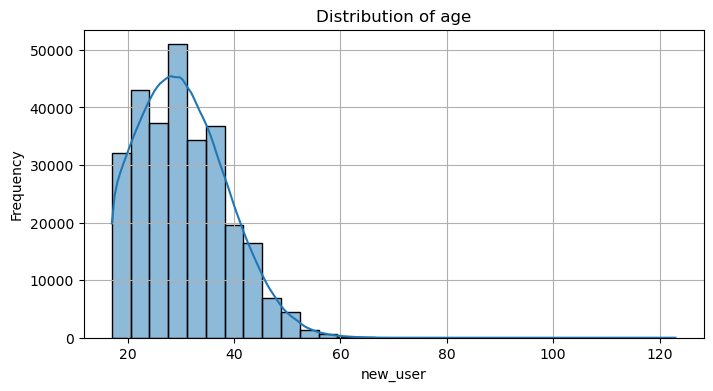

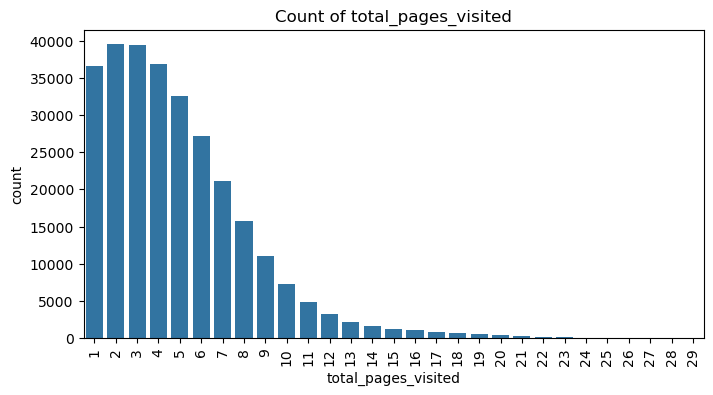

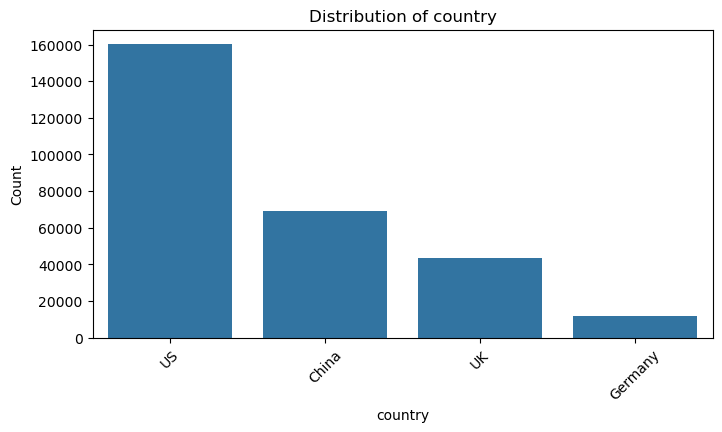

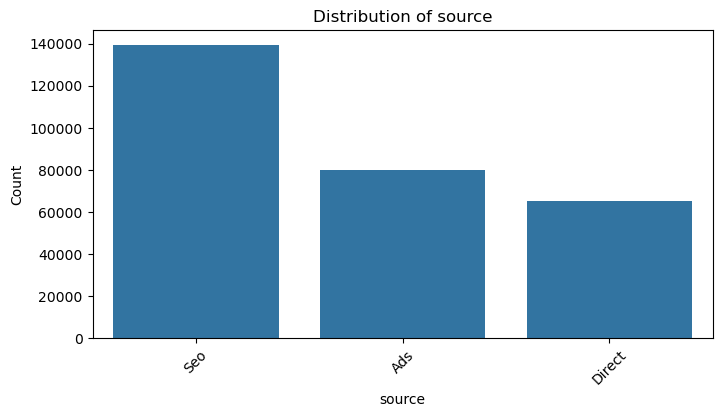

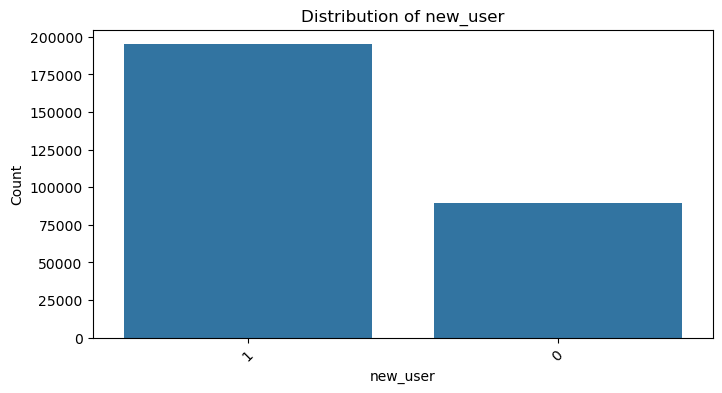

In [11]:
# =============================
# 📊 4. Feature Distributions
# =============================

# Visual distribution of numeric and categorical features

plt.figure(figsize=(8, 4))
sns.histplot(df['age'], kde=True, bins=30)
plt.title(f'Distribution of age')
plt.xlabel(col)
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
sns.countplot(x='total_pages_visited', data=df)
plt.title('Count of total_pages_visited')
plt.xticks(rotation=90)
plt.show()


for col in ['country', 'source', 'new_user']:
    plt.figure(figsize=(8, 4))
    sns.countplot(x=col, data=df, order=df[col].value_counts().index)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.show()

In [ ]:
# =============================
# ✅ Other conclusions
# =============================


# - Four countries are present, although unevenly distributed (with the US and China dominating; there are also two European countries: the UK and Germany)
# - Age ranges from about 20 to 70, with a higher concentration in the 20–40 range (outliers to consider)
# - New_user is a categorical feature (Y/N) that shows a predominance of "Yes" (approximately a 2:1 ratio)
# - Three sources are represented (SEO, Ads, Direct), all of which are fairly balanced, with a slight dominance of SEO
# - Total_pages_visited is a numerical feature ranging from 1 to 29, with the majority falling between 1 and 10

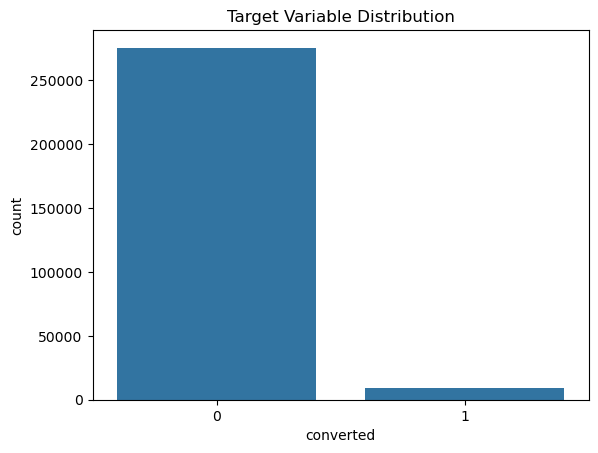

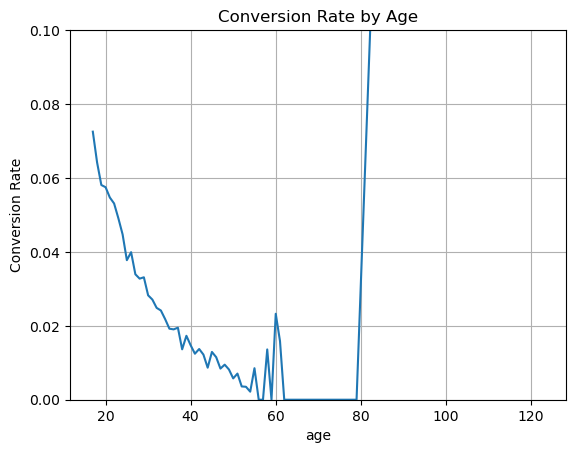



⚠️ Outlier Detection on Age:
age: 1017 outliers (>55.36)




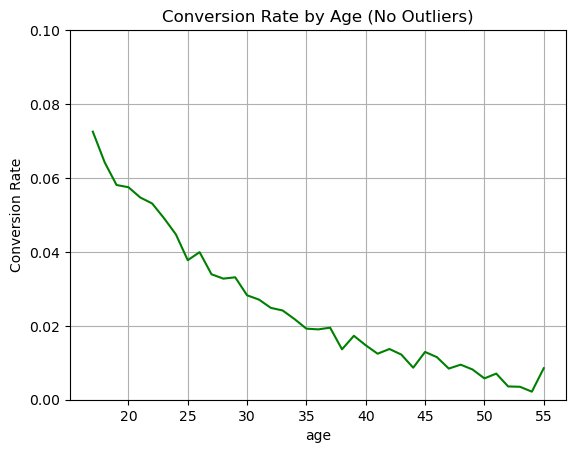

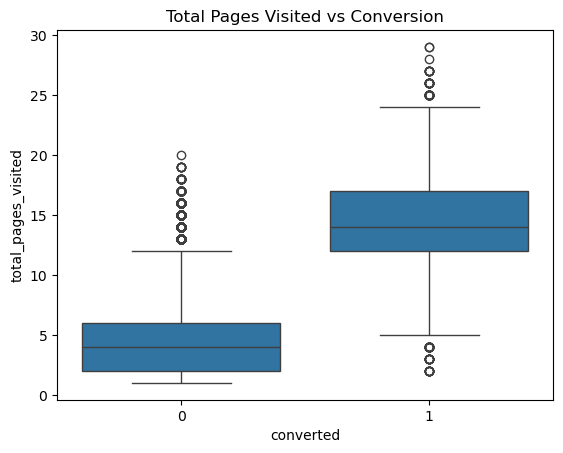

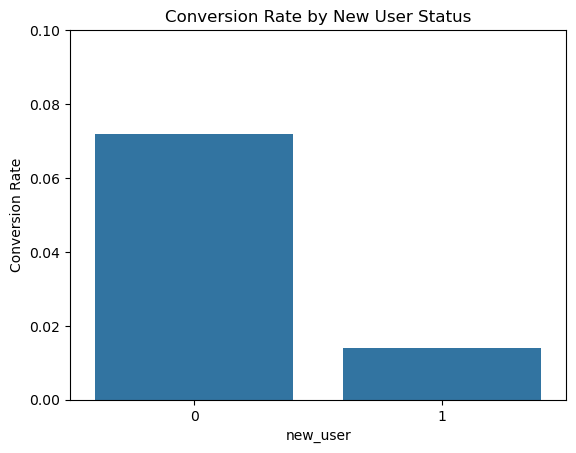

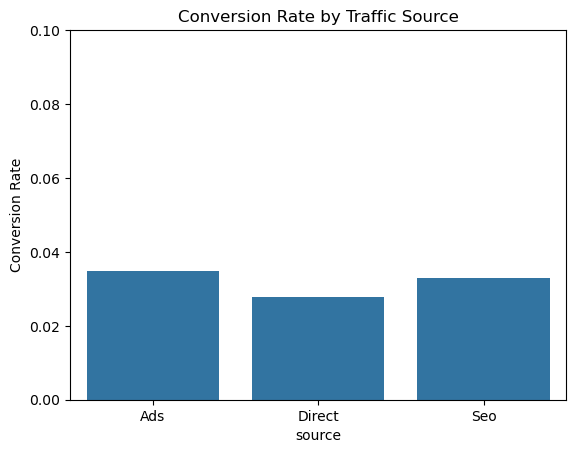

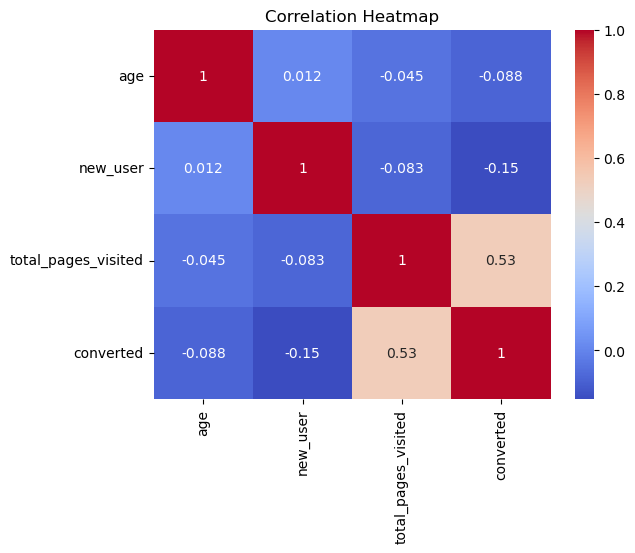

In [ ]:
# =============================
# 📊 5. Quick Visualization of data vs conversion_rate
# =============================

sns.countplot(x='converted', data=df)
plt.title('Target Variable Distribution')
plt.show()

# Visualizing conversion rate by age
age_group = df.groupby('age')['converted'].mean().reset_index()
sns.lineplot(data=age_group, x='age', y='converted')
plt.title('Conversion Rate by Age')
plt.ylabel('Conversion Rate')
plt.ylim(0, 0.1)
plt.grid(True)
plt.show()

# Detecting outliers in 'age' using mean + 3*std
print("\n\n⚠️ Outlier Detection on Age:")
age_mean = df['age'].mean()
age_std = df['age'].std()
age_threshold = age_mean + 3 * age_std
age_outliers = df[df['age'] > age_threshold]
print(f"age: {len(age_outliers)} outliers (>{age_threshold:.2f})")

# Conversion rate by age (without outliers)
print("\n")
df_no_outliers = df[df['age'] <= df['age'].mean() + 3 * df['age'].std()]
age_group_clean = df_no_outliers.groupby('age')['converted'].mean().reset_index()
sns.lineplot(data=age_group_clean, x='age', y='converted', color='green')
plt.title('Conversion Rate by Age (No Outliers)')
plt.ylabel('Conversion Rate')
plt.ylim(0, 0.1)
plt.grid(True)
plt.show()

print("\n")
sns.boxplot(x='converted', y='total_pages_visited', data=df)
plt.title('Total Pages Visited vs Conversion')
plt.show()

print("\n")
# Visualizing conversion rate by new user using barplot
new_user_group = df.groupby('new_user')['converted'].mean().reset_index()
sns.barplot(data=new_user_group, x='new_user', y='converted')
plt.title('Conversion Rate by New User Status')
plt.ylim(0, 0.1)
plt.ylabel('Conversion Rate')
plt.show()

print("\n")
# Visualizing conversion rate by source using barplot
source_group = df.groupby('source')['converted'].mean().reset_index()
sns.barplot(data=source_group, x='source', y='converted')
plt.title('Conversion Rate by Traffic Source')
plt.ylim(0, 0.1)
plt.ylabel('Conversion Rate')
plt.show()

print("\n")
correlation = df.corr(numeric_only=True)
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
# =============================
# ✅ Overall conclusions
# =============================


# - Significant impact of total pages visited, age and new_user
# - Many outliers on age
# - No clear significance of traffic source
# - Class balancing techniques if needed
